# 6.22 The Variational Method and Variational Monte Carlo

<!-- This single H1 (one per notebook, "# <number> <Title>") is the page's
     title: it sets the sidebar entry, breadcrumb, browser tab, and search
     result. The branded banner below is generated by the shared `ecp`
     package, so the look of every notebook in the series lives in one place. -->

In [1]:
from ecp.style import header, use_style

use_style()  # apply the series Matplotlib style
header(
    volume="Volume VI — Quantum Mechanics",
    number="6.22",
    title="The Variational Method and Variational Monte Carlo",
    blurb="A good guess, and a guarantee. When a system is too far from anything "
    "solvable for perturbation theory, we can still bound its ground-state energy "
    "from above with nothing but a trial wavefunction — and the better the guess, the "
    "tighter the bound. We optimize simple trials for the oscillator and hydrogen, "
    "screen the nucleus to solve helium, and then let Monte Carlo sample the "
    "wavefunction directly, arriving at the method that powers much of modern "
    "many-body physics.",
    difficulty="advanced",
    estimate="180–220 min",
)

<ECP header: 2809 chars of HTML>

## Notebook overview

The last notebook gave us perturbation theory, which works when a problem is *close* to a solvable one.
This notebook gives us its complement — the **variational method** — which needs no nearby solvable
Hamiltonian at all, only a plausible **guess** at the shape of the ground-state wavefunction. In return
it hands us something rare in the business of approximation: a **rigorous bound**. For *any* normalized
trial state, the energy expectation $\langle\psi|H|\psi\rangle$ is an **upper bound** on the true
ground-state energy $E_0$, with equality only when $\psi$ *is* the ground state. So we pick a family of
trial wavefunctions with adjustable parameters, minimize the energy over them, and know that whatever we
get can never dip below the truth — *lower is always better*.

We build it in three stages. First the **warm-ups**: a Gaussian trial for the harmonic oscillator and an
exponential for hydrogen, where the trial family happens to *contain* the exact ground state, so the
bound is saturated and we recover $\tfrac12$ and $-\tfrac12\,$Ha exactly — a check that the machinery is
sound. Then the **flagship**: the **helium atom**, where two electrons repel through a $1/r_{12}$ term
that is neither small nor separable and that defeats low-order perturbation theory. A product of two
hydrogenic orbitals with an *effective* nuclear charge $Z$ as the single variational parameter captures
the essential physics — each electron partially **screens** the nucleus from the other, so the charge
each sees is *less* than $Z=2$ — and minimizing gives $Z_{\text{eff}}=27/16\approx1.69$ and an energy of
$-2.85\,$Ha, remarkably close to the experimental $-2.90$ and far better than the unscreened guess. One
parameter buys the screening that perturbation theory missed.

Finally, when the best trial functions grow too tangled to integrate by hand — a wavefunction with an
explicit $r_{12}$ correlation factor — we evaluate $\langle H\rangle$ by **variational Monte Carlo**. We
write it as an average of the **local energy** $E_L=H\psi/\psi$ over the probability distribution
$|\psi|^2$, sample configurations from $|\psi|^2$ with the **Metropolis algorithm** of Volume V ([§5.2](../05-classical-stat-mech/probability.ipynb),
[§5.8](../05-classical-stat-mech/partition-function.ipynb)), and average. The mean is the variational energy; its **variance** measures how far $\psi$ is from an
eigenstate — and *vanishes exactly at the true ground state*. This **zero-variance principle** is the
conceptual heart of the method and the foundation of modern quantum Monte Carlo, the same
sample-a-distribution-and-average-an-estimator logic that runs through computational many-body physics
(and, in a different guise, through the sampling behind machine-learned interatomic potentials).

As in every Volume VI notebook, each exercise opens with a **crystal-clear statement** and enumerated parts, each naming the exact operation — the trial energies via `numpy.trapezoid` or analytic formulas,
`scipy.optimize.minimize_scalar` for the parameter optimization, the Metropolis sampler built on
`numpy.random.default_rng`, and the local energy $E_L=H\psi/\psi$ coded explicitly.

> **Conventions and method notes.** Atomic units ($\hbar=m_e=e=4\pi\varepsilon_0=1$), energies in Hartree
> ($1\,\text{Ha}=27.211\,$eV). Trial forms: Gaussian $e^{-\alpha x^2/2}$ (oscillator), exponential
> $e^{-\alpha r}$ (hydrogen), the product $e^{-Z(r_1+r_2)}$ and its Jastrow-correlated cousin (helium).
> The VMC uses **single-electron** Metropolis moves, a **burn-in** before averaging, a step tuned for an
> acceptance near $0.5$, and a **block-averaged** error bar (honest about the autocorrelation of Metropolis
> samples — a naive $\sigma/\sqrt N$ underestimates it). See Griffiths and Sakurai & Napolitano (the
> variational principle, helium); Thijssen, *Computational Physics*, and Foulkes et al. (Rev. Mod. Phys.
> 2001) for VMC; and Notebooks [§6.21](perturbation-fine-structure.ipynb) (perturbation theory — the complementary method), [§6.17](hydrogen-atom.ipynb) (hydrogenic
> orbitals), [§6.12](harmonic-oscillator.ipynb) (the oscillator), [§5.2](../05-classical-stat-mech/probability.ipynb)/[§5.8](../05-classical-stat-mech/partition-function.ipynb) (Monte Carlo, the Metropolis algorithm).

## Theory in brief

### The variational principle

For any normalized trial state $|\psi\rangle$,

```{math}
:label: eq-variational
\langle\psi|H|\psi\rangle\ge E_0 ,
```

with equality iff $|\psi\rangle$ is the ground state. **Proof:** expand $|\psi\rangle=\sum_n c_n|n\rangle$
in the (unknown) energy eigenbasis; then $\langle H\rangle=\sum_n|c_n|^2 E_n\ge E_0\sum_n|c_n|^2=E_0$,
since every $E_n\ge E_0$. The bound is **one-sided** — the estimate is always *above* the truth, so lower
is better. (Unnormalized: use $\langle\psi|H|\psi\rangle/\langle\psi|\psi\rangle$.)

### The method, and the warm-ups

The bound {eq}`eq-variational` holds for *every* trial state, so it holds in particular for the best
member of any parametrized family $\psi_\alpha$, and that observation is already the whole algorithm:

```{math}
:label: eq-trial
E(\alpha)=\langle\psi_\alpha|H|\psi_\alpha\rangle,\qquad \min_\alpha E(\alpha)\ge E_0 .
```

Choose a family $\psi_\alpha$, compute $E(\alpha)$, minimize. A Gaussian $e^{-\alpha x^2/2}$ for the
oscillator gives $E(\alpha)=\alpha/4+1/4\alpha$, minimized at $\alpha=1\Rightarrow E=\tfrac12=E_0$; an
exponential $e^{-\alpha r}$ for hydrogen gives $E(\alpha)=\alpha^2/2-\alpha$, minimized at $\alpha=1
\Rightarrow-\tfrac12\,$Ha. Both families *contain* the exact ground state, so the bound is **saturated**.

### Helium and screening

Helium is the method's first real test: two electrons bound to a $Z=2$ nucleus, each repelled by the
other. Its Hamiltonian, and the trial energy that a page of hydrogenic integrals produces from it
(Griffiths carries them out), are

```{math}
:label: eq-helium
H=-\tfrac12\nabla_1^2-\tfrac12\nabla_2^2-\frac{2}{r_1}-\frac{2}{r_2}+\frac{1}{r_{12}},\qquad E(Z)=Z^2-\tfrac{27}{8}Z\ \Rightarrow\ Z_{\text{eff}}=\tfrac{27}{16} .
```

The $1/r_{12}$ repulsion is $\sim37\%$ of the binding — not small, and non-separable. The trial
$\psi=e^{-Z(r_1+r_2)}$ with $Z$ variational gives $E(Z)=Z^2-\tfrac{27}{8}Z$ (kinetic $Z^2$, electron–
nucleus $-4Z$, electron–electron $+\tfrac58 Z$), minimized at $Z_{\text{eff}}=27/16\approx1.69<2$:
**screening**. The energy $-2.85\,$Ha beats the unscreened $Z=2$ value ($-2.75$) and nears experiment
($-2.90$); the residual gap is **correlation**, which the Monte Carlo below addresses.

### Variational Monte Carlo and the local energy

When the trial function grows too tangled for closed-form integrals, we evaluate $\langle H\rangle$
statistically instead. Multiplying and dividing the integrand of $\int\psi^* H\psi$ by $\psi$ recasts
the expectation value as

```{math}
:label: eq-vmc
\langle H\rangle=\frac{\int|\psi|^2 E_L}{\int|\psi|^2},\qquad E_L(R)=\frac{H\psi(R)}{\psi(R)} ,
```

an average of the **local energy** $E_L$ over $|\psi|^2$. Sample configurations $R$ from $|\psi|^2$ with
**Metropolis** ([§5.2](../05-classical-stat-mech/probability.ipynb)/[§5.8](../05-classical-stat-mech/partition-function.ipynb): propose a move, accept with probability $\min(1,|\psi_{\text{new}}|^2/
|\psi_{\text{old}}|^2)$) and average $E_L$; the statistical error is $\sim\sigma(E_L)/\sqrt N$. This
evaluates trial functions — like one with an explicit $r_{12}$ **Jastrow** correlation factor — that have
no closed-form integral.

### The zero-variance principle

The local energy is more than a computational device, and one substitution shows why: feed an exact
eigenstate into its definition {eq}`eq-vmc` and the wavefunction cancels,

```{math}
:label: eq-zero-variance
H\psi=E\psi\ \Rightarrow\ E_L=\frac{H\psi}{\psi}=E\ \text{(constant)},\quad \mathrm{Var}(E_L)=0 .
```

If $\psi$ is an **exact** eigenstate, $E_L$ is the *same everywhere* — its variance is zero. So
$\mathrm{Var}(E_L)$ measures how far $\psi$ is from an eigenstate, and minimizing it optimizes trial
functions. This **zero-variance principle** is the foundation of modern quantum Monte Carlo.

## Setup

Data and instruments only: the series palette, the Hartree conversion and the experimental helium
energy, the three closed-form trial energies $E(\alpha)$ and $E(Z)$ that a page of hydrogenic
integrals hands us (Griffiths carries them out — they are the specimens, not the method), the
Jastrow exponent $u(r_{12})$, and `optimize_trial`, a bounded wrapper around
`scipy.optimize.minimize_scalar`. The two objects variational Monte Carlo *is* are deliberately
absent: you write the helium local energy $E_L=H\psi/\psi$ and the Metropolis sampler yourself in
Exercise 5, and Exercises 7 and 8 run the sampler you wrote.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize_scalar

from ecp import draw, validate

ACCENT, INK, SOFT = draw.ACCENT, draw.INK, draw.SOFT  # data: the series palette
RED = "#c1121f"

HARTREE_EV = 27.211386  # data: 1 Hartree in eV
HE_EXPERIMENT = (
    -2.9037
)  # data: helium ground state (non-relativistic, infinite nuclear mass), Ha


# data: a given closed form — the Gaussian integrals are carried out for us in the theory above,
# so there is nothing here for the reader's fingers to do but transcribe the displayed equation.
def variational_energy_oscillator(alpha):
    r"""The oscillator trial energy $E(\alpha)=\alpha/4+1/4\alpha$ for $\psi_\alpha=e^{-\alpha x^2/2}$ {eq}`eq-trial`."""
    return alpha / 4 + 1 / (4 * alpha)


# data: a given closed form, as above — the hydrogenic integrals are done in the theory section.
def variational_energy_hydrogen(alpha):
    r"""The hydrogen trial energy $E(\alpha)=\alpha^2/2-\alpha$ for $\psi_\alpha=e^{-\alpha r}$ {eq}`eq-trial`."""
    return alpha**2 / 2 - alpha


# data: the specimen this notebook's flagship problem hands us — the page of hydrogenic integrals
# behind $E(Z)=Z^2-\tfrac{27}{8}Z$ is Griffiths' work, quoted in {eq}`eq-helium`, not the lesson here.
def variational_energy_helium(Z):
    r"""The helium trial energy $E(Z)=Z^2-\tfrac{27}{8}Z$ for $\psi=e^{-Z(r_1+r_2)}$ {eq}`eq-helium`."""
    return Z**2 - (27 / 8) * Z


# instrument: a thin bounded wrapper over scipy.optimize.minimize_scalar — the lesson of the
# variational method is which $E(\alpha)$ to minimize and what its minimum means, never how to
# call a one-dimensional minimizer.
def optimize_trial(energy_of_param, bounds):
    """Minimize a trial energy over its parameter with ``scipy.optimize.minimize_scalar`` (bounded).

    Returns the minimizing parameter and the minimum energy — the best (lowest, hence tightest) bound in
    the family {eq}`eq-trial`.
    """
    result = minimize_scalar(energy_of_param, bounds=bounds, method="bounded")
    return result.x, result.fun


# data: the given Jastrow correlation exponent, a one-line specified form (Exercise 8 states it).
# The Metropolis sampler you write in Exercise 5 calls this — Python resolves the name at call time.
def _jastrow(r12, b):
    r"""The Jastrow correlation exponent $u(r_{12})=\tfrac12 r_{12}/(1+b\,r_{12})$ (keeps the electrons apart)."""
    return 0.5 * r12 / (1 + b * r12)

## Exercise 1 — The variational principle

Everything in this notebook rests on one inequality, and the inequality costs two lines of algebra
{eq}`eq-variational`. Expand a normalized trial state in the (unknown) energy eigenbasis,
$|\psi\rangle=\sum_n c_n|n\rangle$; then $\langle H\rangle=\sum_n|c_n|^2E_n\ge E_0\sum_n|c_n|^2=E_0$,
because every $E_n\ge E_0$. Equality requires all the weight on the ground state. An inequality this
cheap deserves a numerical test, and a small Hermitian matrix is the ideal specimen: its $E_0$ is the
lowest eigenvalue (`numpy.linalg.eigvalsh`), so every trial vector can be scored against the truth.

1. Build a solvable model $H$ — a random Hermitian $6\times6$ matrix — and take its exact $E_0$ from
   `numpy.linalg.eigvalsh`.
2. Draw many random normalized trial vectors and compute
   $\langle\psi|H|\psi\rangle/\langle\psi|\psi\rangle$ for each.
3. Confirm every one is $\ge E_0$, and that the ground eigenvector attains equality. The estimate is
   always an upper bound — lower is better.

In [3]:
# (solution hidden on the public site)


exact ground-state energy E₀ = -5.2726
of 5000 random trial states, 5000 satisfy ⟨H⟩ ≥ E₀   (100.0%)
the exact ground state attains equality: ⟨H⟩ = -5.2726 = E₀


### Validation 1

In [4]:
validate.check(
    principle_ok,
    "the variational principle bounds the ground-state energy from above: ⟨H⟩ ≥ E₀ for every trial state, with equality at the ground state",
)

✓  the variational principle bounds the ground-state energy from above: ⟨H⟩ ≥ E₀ for every trial state, with equality at the ground state


True

## Exercise 2 — Optimizing a trial: the oscillator

The natural one-parameter family for the harmonic oscillator is the Gaussian
$\psi_\alpha=e^{-\alpha x^2/2}$, whose width $\alpha$ is the knob. Doing the two Gaussian integrals
gives the trial energy $E(\alpha)=\alpha/4+1/4\alpha$ {eq}`eq-trial` — Setup's
`variational_energy_oscillator`, a specimen handed to us rather than machinery to build. This family
is a lucky one: the exact ground state of the oscillator *is* a Gaussian, so the family **contains**
the answer, the bound is saturated, and the minimum should land exactly on $E_0=\tfrac12$ at
$\alpha=1$.

1. Minimize $E(\alpha)$ over $\alpha$ with `optimize_trial` (bounded
   `scipy.optimize.minimize_scalar`).
2. Confirm the minimum is $E_0=\tfrac12$, attained at $\alpha=1$.
3. Report what saturation means here: when the family is right, the bound is exact.

In [5]:
# (solution hidden on the public site)


oscillator Gaussian trial e^(−αx²/2):  min E(α) = 0.50000 at α = 1.0000
  exact ground state E₀ = 0.5 (the trial contains it → bound saturated)


### Validation 2

In [6]:
validate.close(
    E_star,
    0.5,
    "the Gaussian trial saturates the oscillator ground-state energy (E₀=½ at α=1)",
    atol=1e-3,
)

✓  the Gaussian trial saturates the oscillator ground-state energy (E₀=½ at α=1)   [got 0.5 vs expected 0.5 (rtol=1e-06, atol=0.001)]


True

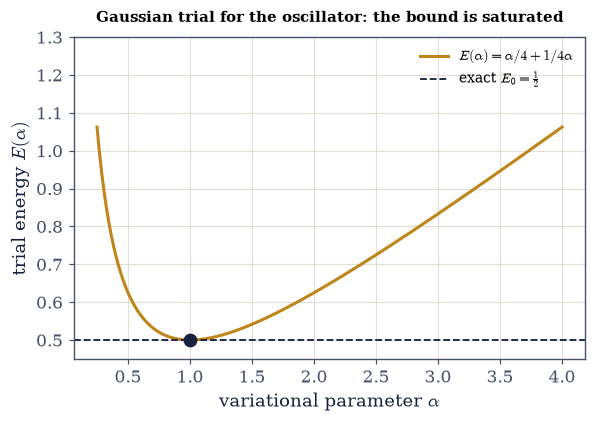

In [7]:
# (solution hidden on the public site)


## Exercise 3 — Optimizing a trial: hydrogen

Hydrogen is a second saturated bound, and the warm-up that matters most: the exponential family
$\psi_\alpha=e^{-\alpha r}$ is the one that will reappear, doubled, as helium's product trial. The
hydrogenic integrals give $E(\alpha)=\alpha^2/2-\alpha$ {eq}`eq-trial` — Setup's
`variational_energy_hydrogen`, again a given closed form. At $\alpha=1$ this trial *is* the exact
$1s$ orbital of [§6.17](hydrogen-atom.ipynb), so the family contains the ground state and the
minimum must be $-\tfrac12\,$Ha exactly.

1. Minimize $E(\alpha)$ with `optimize_trial`.
2. Confirm the minimum is $-\tfrac12\,$Ha, attained at $\alpha=1$.
3. Report the optimal $\alpha$ against the exact $1s$ decay constant.

In [8]:
# (solution hidden on the public site)


hydrogen exponential trial e^(−αr):  min E(α) = -0.50000 Ha at α = 1.0000
  exact ground state −0.5 Ha (the trial at α=1 is the exact 1s orbital, 6.17)


### Validation 3

In [9]:
validate.close(
    E_h,
    -0.5,
    "the exponential trial saturates the hydrogen ground-state energy (−0.5 Ha at α=1)",
    atol=1e-3,
)

✓  the exponential trial saturates the hydrogen ground-state energy (−0.5 Ha at α=1)   [got -0.5 vs expected -0.5 (rtol=1e-06, atol=0.001)]


True

## Exercise 4 — Helium and screening

Helium is the method's first real test. Its Hamiltonian carries a $1/r_{12}$ repulsion that is
neither small nor separable {eq}`eq-helium`, and the trial that meets it is the product of two
hydrogenic orbitals, $\psi=e^{-Z(r_1+r_2)}$, with the nuclear charge $Z$ demoted to a variational
parameter. A page of hydrogenic integrals (Griffiths carries them out) turns that trial into
$E(Z)=Z^2-\tfrac{27}{8}Z$ — kinetic $Z^2$, electron–nucleus $-4Z$, electron–electron $+\tfrac58Z$ —
which is Setup's `variational_energy_helium`. Two comparisons make the result speak: the
experimental $-2.9037\,$Ha, and the unscreened evaluation at the bare $Z=2$.

1. Minimize $E(Z)$ with `optimize_trial` and confirm $Z_{\text{eff}}=27/16\approx1.69$ — *less*
   than the bare nuclear charge.
2. Evaluate the energy there, and evaluate the unscreened $E(2)$ for contrast.
3. Compare both to experiment and report the residual gap. Each electron screens the nucleus from
   the other, and one variational parameter finds it.

In [10]:
# (solution hidden on the public site)


helium product trial e^(−Z(r₁+r₂)):  E(Z) = Z² − (27/8)Z
  minimized: Z_eff = 1.68750  (= 27/16 = 1.68750) — LESS than 2: screening
  variational energy E = -2.8477 Ha = -77.49 eV
  vs experiment -2.9037 Ha,  vs unscreened Z=2: -2.7500 Ha
  one parameter recovers most of the binding; the residual gap (+0.056 Ha) is correlation


### Validation 4

In [11]:
validate.close(
    np.array([Z_eff, E_helium]),
    np.array([27 / 16, -2.8477]),
    "helium's screened variational energy (Z_eff=27/16, E=−2.85 Ha) is close to experiment and beats the unscreened guess",
    rtol=1e-3,
)

✓  helium's screened variational energy (Z_eff=27/16, E=−2.85 Ha) is close to experiment and beats the unscreened guess   [max|Δ| = 4.375e-05 (rtol=0.001, atol=1e-09)]


True

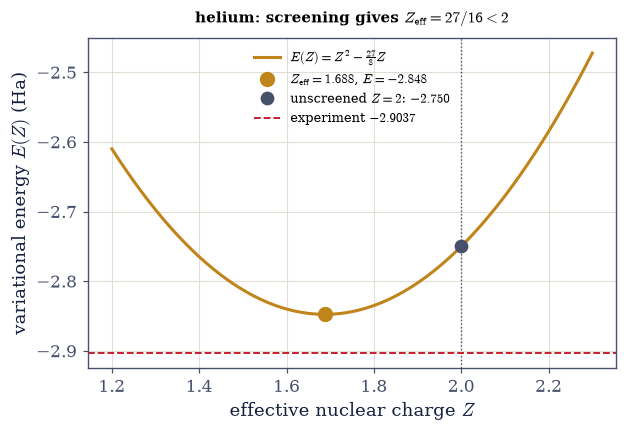

In [12]:
# (solution hidden on the public site)


## Exercise 5 — Variational Monte Carlo: the local energy

Multiplying and dividing the integrand of $\int\psi^*H\psi$ by $\psi$ turns the expectation value
into an average of the **local energy** $E_L=H\psi/\psi$ over the probability density $|\psi|^2$
{eq}`eq-vmc`. That single algebraic move is what lets Monte Carlo evaluate a six-dimensional
integral by sampling — the sampling spine of Volume V ([§5.2](../05-classical-stat-mech/probability.ipynb),
[§5.8](../05-classical-stat-mech/partition-function.ipynb)) turned on wavefunctions. Two objects are
needed, and this exercise is where they are written.

The first is the local energy itself. For the helium product trial $\psi=e^{-Z(r_1+r_2)}$, applying
$H$ and dividing gives $E_L=-Z^2+(Z-2)(1/r_1+1/r_2)+1/r_{12}$. Multiplying that trial by a Jastrow
factor $e^{u(r_{12})}$ with $u=\tfrac12 r_{12}/(1+b\,r_{12})$ (Exercise 8's business) adds a kinetic
contribution, which we quote rather than derive: writing $u'=\tfrac12/(1+b r_{12})^2$ and
$u''=-b/(1+b r_{12})^3$, the extra term is $-u'^2-u''-2u'/r_{12}+Z\,u'\,(\hat r_1-\hat r_2)\cdot\hat r_{12}$,
with $\hat r_{12}=(\mathbf r_1-\mathbf r_2)/r_{12}$. (It was checked against a finite-difference
Laplacian to a part in $10^7$.)

The second is the sampler. Metropolis on $|\psi|^2$ never needs the normalization: propose a move of
one electron, accept it with probability $\min(1,|\psi_{\text{new}}|^2/|\psi_{\text{old}}|^2)$, and
the chain visits configurations with the right frequency. Work with $\ln|\psi|$ throughout and
accept when $\ln\xi<2\,\Delta\ln|\psi|$ for a uniform deviate $\xi$, which keeps the ratio from
overflowing and costs one logarithm. Two
practicalities matter: a **burn-in** discarded before averaging, and a **block-averaged** error bar,
because Metropolis samples are correlated and a naive $\sigma/\sqrt N$ would flatter us. The product
trial has a closed-form energy, so this first run can be graded against an answer we already know.

1. Write `local_energy_helium(r1, r2, Z, b=0.0)` for the two electron position 3-vectors, returning
   the product-trial $E_L$ above and, when `b` is nonzero, adding the quoted Jastrow term.
   **Write this one yourself** — the implementation is the lesson.
2. Write `metropolis_vmc(Z, b=0.0, n_steps=120000, step=0.6, burn=8000, n_blocks=80, seed=1)`:
   single-electron moves proposed as $r_i\to r_i+\text{step}\cdot\mathcal N(0,1)$ with
   `numpy.random.default_rng`, the acceptance test above, and after the burn-in an average of
   `local_energy_helium`. Return the mean, the block-averaged error, the local-energy standard
   deviation, and the acceptance rate. **Write this one yourself** — the implementation is the lesson.
3. Run it on the product trial at the $Z_{\text{eff}}$ of Exercise 4 and confirm the mean matches the
   analytic $E(Z_{\text{eff}})=-2.85\,$Ha, quoting the discrepancy in units of the error bar.

In [13]:
# (solution hidden on the public site)


helium VMC (product trial, Z_eff=1.6875), Metropolis sampling of |ψ|²:
  VMC energy = -2.8460 ± 0.0113 Ha   (analytic -2.8477 Ha)
  agreement: 0.1σ;   acceptance = 0.40;   local-energy spread σ(E_L) = 0.86
  the mean local energy reproduces the analytic ⟨H⟩ — Monte Carlo did the 6-D integral by sampling


### Validation 5

In [14]:
validate.check(
    vmc_ok,
    "VMC reproduces the analytic variational energy of the helium product trial (within a few statistical error bars)",
)

✓  VMC reproduces the analytic variational energy of the helium product trial (within a few statistical error bars)


True

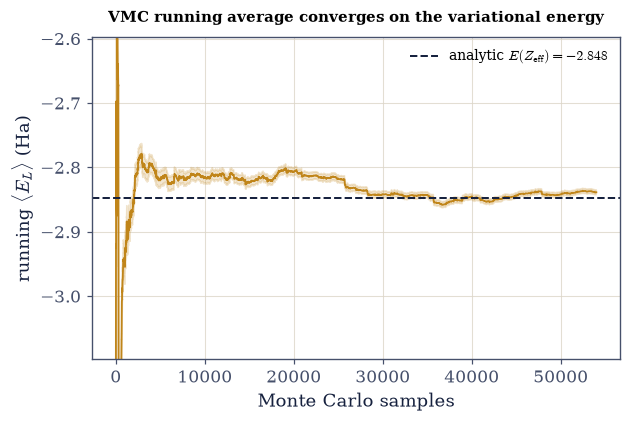

In [15]:
# (solution hidden on the public site)


## Exercise 6 — The zero-variance principle

The local energy is more than a computational device, and one substitution shows why: if
$H\psi=E\psi$ then $E_L=H\psi/\psi=E$ identically, the same number at every configuration, so
$\mathrm{Var}(E_L)=0$ {eq}`eq-zero-variance`. The variance is therefore a *second* quality meter,
independent of the mean: it measures how far a trial is from being an eigenstate, and it vanishes
only at the exact answer. That is the foundation of quantum Monte Carlo — and, in spirit, of
sampling-based optimization generally, since a quantity one can drive to a known floor is a
quantity one can optimize against. Hydrogen makes the point in one line: for
$\psi_\alpha=e^{-\alpha r}$, applying $H$ and dividing gives $E_L=-\alpha^2/2+(\alpha-1)/r$, whose
$r$-dependence switches off precisely at $\alpha=1$.

1. Write `hydrogen_local_energy(r, alpha)` returning $E_L=-\alpha^2/2+(\alpha-1)/r$.
2. Evaluate it on a radial grid at $\alpha=1$ (the exact ground state) and confirm $E_L=-\tfrac12$
   *everywhere* — zero spread.
3. Evaluate it at $\alpha=0.7$ and $\alpha=1.3$ and report the spread that appears once the trial
   is no longer an eigenstate.

In [16]:
# (solution hidden on the public site)


hydrogen local energy E_L = −α²/2 + (α−1)/r:
  α=1.0:  E_L std over r = 0.0000  ← EXACT ground state: E_L constant everywhere (zero variance!)
  α=0.7:  E_L std over r = 0.3637
  α=1.3:  E_L std over r = 0.3637


### Validation 6

In [17]:
validate.close(
    zero_var_std,
    0.0,
    "the local energy is constant at the exact ground state (α=1) — the zero-variance principle",
    atol=1e-9,
)

✓  the local energy is constant at the exact ground state (α=1) — the zero-variance principle   [got 0 vs expected 0 (rtol=1e-06, atol=1e-09)]


True

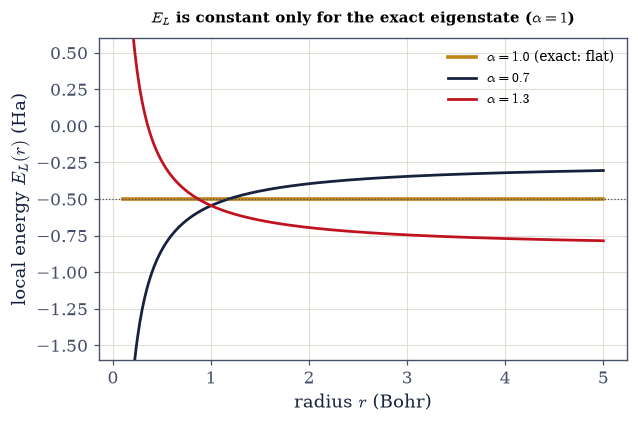

In [18]:
# (solution hidden on the public site)


## Exercise 7 — Practical VMC: tuning and error bars *(student)*

A Monte Carlo result is not a number but a number with a texture, and that texture has two knobs
{eq}`eq-vmc`. The first is the proposal step: too large and almost every move is rejected, so the
chain sits still; too small and every move is accepted but the walk crawls, exploring configuration
space at a snail's pace. The practitioner's compromise is a step tuned for an acceptance rate near
$\sim0.5$. The second is the sample count, which buys precision only as $\sqrt N$ — sixteen times
the samples for four times the accuracy. Both come with a third habit, the burn-in discarded before
averaging, so the chain's memory of its arbitrary starting configuration does not contaminate the
mean.

1. Run the `metropolis_vmc` you wrote in Exercise 5 at several step sizes and record the acceptance
   rate at each.
2. Identify the step giving an acceptance near $\sim0.5$, and confirm the rate falls monotonically
   through it as the step grows.
3. At that well-tuned step, run at increasing sample counts and show the error bar shrinks as
   $\sim1/\sqrt N$. Step tuning, equilibration, and error bars are features of a stochastic
   calculation, not bugs.

In [19]:
# (solution hidden on the public site)


step-size tuning (acceptance rate vs Metropolis step):


  step = 0.2:  acceptance = 0.74


  step = 0.4:  acceptance = 0.54  ← near 0.5 (well-tuned)


  step = 0.6:  acceptance = 0.40


  step = 1.0:  acceptance = 0.21


  step = 1.6:  acceptance = 0.10

error bar shrinks as ~1/√N (at the well-tuned step 0.4):
  N =  10000:  error = 0.03200 Ha


  N =  40000:  error = 0.01271 Ha


  N = 160000:  error = 0.00703 Ha

  acceptance decreases through 0.5 (tunable): True;   error drops 4.6× for N ×16 (1/√N): True


### Validation 7

In [20]:
validate.check(
    good_step and sqrtN_ok,
    "practical VMC requires step tuning (acceptance ~0.5), equilibration, and reports a statistical error bar that scales as 1/√N",
)

✓  practical VMC requires step tuning (acceptance ~0.5), equilibration, and reports a statistical error bar that scales as 1/√N


True

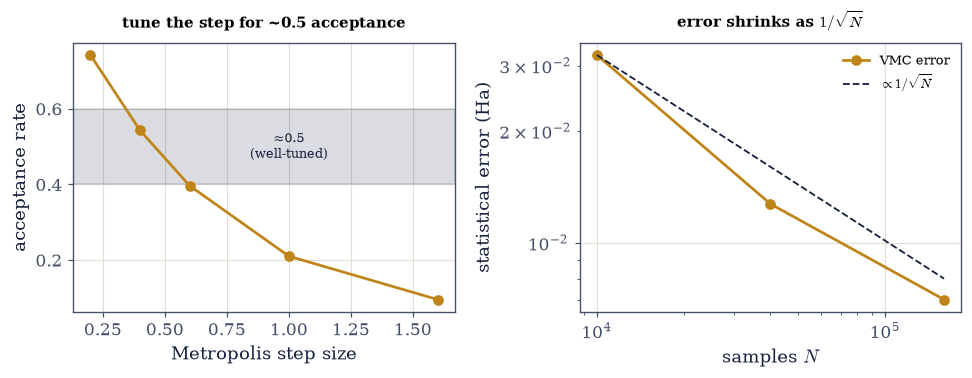

In [21]:
# (solution hidden on the public site)


## Exercise 8 — A Jastrow factor beats the product trial *(student / stretch)*

The product trial $e^{-Z(r_1+r_2)}$ treats the two electrons as independent, each feeling only a
mean screened charge; what it cannot represent is their *instantaneous* avoidance. The standard
repair multiplies it by a **Jastrow** factor $e^{u(r_{12})}$ with $u=\tfrac12 r_{12}/(1+b\,r_{12})$,
a function that grows with the electron separation and so suppresses configurations where the two
come close. No closed-form integral survives this — which is exactly why Monte Carlo was built in
Exercise 5, and why the local energy there already carries the $b>0$ branch. With $Z=1.85$ and
$b=0.35$ the correlated trial should improve on *both* meters at once {eq}`eq-vmc`,
{eq}`eq-zero-variance`: a lower energy, still bounded from below by the truth, and a smaller
local-energy spread, because the Jastrow removes the electron-coalescence mismatch that made $E_L$
noisy.

1. Run the `metropolis_vmc` you wrote in Exercise 5 twice under identical sampling: the product
   trial at $Z_{\text{eff}}$ with $b=0$, and the Jastrow trial at $Z=1.85$, $b=0.35$.
2. Show the Jastrow energy is *lower* than the product trial's and closer to $-2.90\,$Ha, while
   still lying above it.
3. Show the local-energy spread $\sigma(E_L)$ is *smaller*. Better trials, better bounds — the path
   modern QMC takes.

In [22]:
# (solution hidden on the public site)


helium VMC: product trial vs Jastrow-correlated trial
  product  (Z=27/16):        E = -2.8460 ± 0.0113 Ha,  σ(E_L) = 0.86
  Jastrow  (Z=1.85, b=0.35): E = -2.8832 ± 0.0052 Ha,  σ(E_L) = 0.33
  experiment = -2.9037 Ha
  → Jastrow LOWER than product (-2.883 < -2.846), toward experiment; and variance REDUCED (0.33 < 0.86)
  the r₁₂ factor captures correlation — the electrons' instantaneous avoidance — a product cannot


### Validation 8

In [23]:
validate.check(
    jastrow_ok,
    "explicit correlation improves the variational energy: the Jastrow trial lowers the VMC energy below the product trial toward experiment, with reduced variance",
)

✓  explicit correlation improves the variational energy: the Jastrow trial lowers the VMC energy below the product trial toward experiment, with reduced variance


True

## Exercise 9 — A guess with a guarantee *(synthesis)*

The variational method asks only for a plausible *shape* and returns something rare in approximation: a
rigorous bound, never below the truth, so that lowering the energy always means getting closer. We watched
it **saturate** for the oscillator and hydrogen, where the trial family contained the exact state; then
**screen** the nucleus to solve helium with a single parameter ($Z_{\text{eff}}=27/16$) where low-order
perturbation theory faltered on the electron–electron repulsion; and finally, when the best trial
functions grew too tangled to integrate, we handed the wavefunction to **Monte Carlo** and averaged the
local energy — whose *stillness* at the exact ground state (the zero-variance principle) is the idea the
whole method turns on.

There is no new computation here; the method, and its honesty, are the result.
Perturbation theory ([§6.21](perturbation-fine-structure.ipynb)) and the variational method are the **two hands** of approximate quantum
mechanics — one expands around what you can solve, the other guesses the answer and bounds its error. The
variational method's quiet strength is exactly that honesty: it can be wrong, but never *optimistically*,
and Monte Carlo lets the guess be as elaborate as the physics demands. This VMC machinery — Metropolis
sampling of $|\psi|^2$, local-energy averaging, variance as a quality measure — is the foundation of
modern electronic-structure and many-body computation, and it is the same sample-and-average logic that
underlies stochastic methods far beyond it, from diffusion Monte Carlo to the sampling behind
machine-learned interatomic potentials. The next notebook ([§6.23](wkb-semiclassical.ipynb)) turns to the opposite regime — not a
good guess at the wavefunction, but the short-wavelength limit where quantum mechanics shades into the
classical action of Volume II: the **WKB approximation**.

## Notebook summary

The variational method — a guess with a guarantee — and variational Monte Carlo.

- **The variational principle** {eq}`eq-variational`: $\langle\psi|H|\psi\rangle\ge E_0$ for any trial
  (proven by expanding in the eigenbasis) — an upper bound, so lower is better.
- **Optimizing trials** {eq}`eq-trial`: minimize $E(\alpha)$ (`scipy.optimize.minimize_scalar`); the
  Gaussian oscillator and exponential hydrogen trials saturate at $\tfrac12$ and $-\tfrac12\,$Ha.
- **Helium and screening** {eq}`eq-helium`: $E(Z)=Z^2-\tfrac{27}{8}Z$ gives $Z_{\text{eff}}=27/16<2$ and
  $-2.85\,$Ha — screening captured by one parameter, where perturbation theory struggles.
- **Variational Monte Carlo** {eq}`eq-vmc`: $\langle H\rangle=\langle E_L\rangle_{|\psi|^2}$ with $E_L=
  H\psi/\psi$, by Metropolis sampling (`numpy.random.default_rng`, [§5.2](../05-classical-stat-mech/probability.ipynb)/[§5.8](../05-classical-stat-mech/partition-function.ipynb)) — reproduces the analytic
  energy, with block-averaged error bars, tuned steps ($\sim0.5$ acceptance), and $1/\sqrt N$ convergence.
- **The zero-variance principle** {eq}`eq-zero-variance`: $E_L$ is constant at an exact eigenstate; its
  variance gauges trial quality — the foundation of quantum Monte Carlo. A Jastrow factor lowers helium's
  energy toward experiment with reduced variance.

A plausible shape, a rigorous bound, and Monte Carlo to make the guess as rich as the physics needs.
Next: the semiclassical limit.

## Outlook

- **The WKB / semiclassical approximation ([§6.23](wkb-semiclassical.ipynb))**: the short-wavelength limit and the classical action —
  the connection to the Hamilton–Jacobi theory of Volume II ([§2.10](../02-classical-mechanics/hamilton-jacobi.ipynb)).
- **Time-dependent perturbation theory and Fermi's golden rule ([§6.24](time-dependent-perturbation.ipynb))**: transitions and spectra.
- **Quantum Monte Carlo beyond VMC**: diffusion Monte Carlo, the fermion sign problem, electronic-structure
  methods (horizons — and a nod to the sampling that powers modern computational materials science).
- **Correlation and the many-electron problem**: Hartree–Fock and beyond (horizons; Volume VII / quantum
  chemistry).
- **Cross-reference** [§6.21](perturbation-fine-structure.ipynb) (perturbation theory — the complementary method), [§6.17](hydrogen-atom.ipynb) (hydrogenic orbitals),
  [§6.12](harmonic-oscillator.ipynb) (the oscillator), [§5.2](../05-classical-stat-mech/probability.ipynb)/[§5.8](../05-classical-stat-mech/partition-function.ipynb) (Monte Carlo / Metropolis), and forward to [§6.23](wkb-semiclassical.ipynb), [§6.24](time-dependent-perturbation.ipynb).

In [24]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>